In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd

REPO_ROOT = Path("..").resolve()
STEP_DIR  = REPO_ROOT / "data/raw/step_responses"
SWEEP_CSV = REPO_ROOT / "data/raw/static_sweep_20260506_run1.csv"

STEP_START_MS = 500
SS_WINDOW_MS  = (4000, 5000)

In [2]:
PATTERN = re.compile(r"step_up_(fwd|rev)_pwm(\d+)_run(\d+)\.csv$")
FIRMWARE_PATTERN = re.compile(r"step_up_(fwd|rev)_(\d+)_run0?(\d+)\.csv$")

trials = {}
for f in sorted(STEP_DIR.glob("step_up_*.csv")):
    m = PATTERN.search(f.name) or FIRMWARE_PATTERN.search(f.name)
    if not m:
        print(f"  SKIP (no match): {f.name}")
        continue
    direction, pwm, run = m.group(1), int(m.group(2)), int(m.group(3))
    trials[(direction, pwm, run)] = pd.read_csv(f)

print(f"Loaded {len(trials)} step-up trials")
print("Conditions:", sorted({(d, p) for (d, p, _) in trials.keys()}))

Loaded 18 step-up trials
Conditions: [('fwd', 160), ('fwd', 200), ('fwd', 240), ('rev', 160), ('rev', 200), ('rev', 240)]


In [3]:
def ss_rpm(df):
    lo, hi = SS_WINDOW_MS
    mask = (df["t_ms"] >= lo + STEP_START_MS) & (df["t_ms"] <= hi + STEP_START_MS)
    return df.loc[mask, "rpm"].mean()

records = []
for (direction, pwm, run), df in trials.items():
    records.append({"direction": direction, "pwm": pwm, "run": run, "rpm_ss": ss_rpm(df)})

ss_df = pd.DataFrame(records)

agg = (ss_df.groupby(["direction", "pwm"])["rpm_ss"]
            .agg(["mean", "std", "count"])
            .reset_index()
            .rename(columns={"mean": "rpm_step_mean", "std": "rpm_step_std"}))
print(agg.to_string(index=False))

direction  pwm  rpm_step_mean  rpm_step_std  count
      fwd  160      52.358959      3.142775      3
      fwd  200     123.885385      1.308000      3
      fwd  240     210.509000      4.706710      3
      rev  160     -69.753217      1.826446      3
      rev  200    -131.836073      0.688417      3
      rev  240    -222.733367      2.513944      3


In [4]:
sweep = pd.read_csv(SWEEP_CSV)
print("Sweep columns:", list(sweep.columns))
print(sweep.head())

Sweep columns: ['pwm_cmd', 'direction', 'vmean_v', 'rpm', 'notes']
   pwm_cmd direction  vmean_v  rpm  \
0       10       fwd   -0.220  0.0   
1       20       fwd   -0.247  0.0   
2       30       fwd   -0.240  0.0   
3       40       fwd   -0.245  0.0   
4       50       fwd   -0.355  0.0   

                                               notes  
0  Ch1=12.2; Ch2=12.4; Math=-220mV; PSU_current_A...  
1  Ch1=11.7; Ch2=11.9; Math=-247mV; PSU_current_A...  
2  Ch1=11.2; Ch2=11.3; Math=-240mV; PSU_current_A...  
3  Ch1=10.7; Ch2=10.8; Math=-245mV; PSU_current_A...  
4  Ch1=3.9-4.1V; Ch2=4.7V; Math=-355mV; PSU_curre...  


In [5]:
sweep_points = sweep[sweep["pwm_cmd"].isin([160, 200, 240])].copy()
sweep_points = sweep_points.rename(columns={"pwm_cmd": "pwm", "rpm": "rpm_sweep"})
sweep_points = sweep_points[["direction", "pwm", "vmean_v", "rpm_sweep"]]

xval = agg.merge(sweep_points, on=["direction", "pwm"], how="inner")
xval["disagreement_pct"] = 100.0 * (xval["rpm_step_mean"].abs() - xval["rpm_sweep"].abs()) / xval["rpm_sweep"].abs()
xval = xval[[
    "direction", "pwm", "vmean_v", "rpm_sweep",
    "rpm_step_mean", "rpm_step_std", "count", "disagreement_pct"
]].sort_values(["pwm", "direction"]).reset_index(drop=True)

print("Cross-val against run01 static sweep:")
print(xval.to_string(index=False))

Cross-val against run01 static sweep:
direction  pwm  vmean_v  rpm_sweep  rpm_step_mean  rpm_step_std  count  disagreement_pct
      fwd  160     2.20       70.0      52.358959      3.142775      3        -25.201488
      rev  160    -3.48      -78.5     -69.753217      1.826446      3        -11.142399
      fwd  200     4.85      130.5     123.885385      1.308000      3         -5.068671
      rev  200    -5.79     -135.0    -131.836073      0.688417      3         -2.343649
      fwd  240     8.41      223.0     210.509000      4.706710      3         -5.601345
      rev  240    -8.93     -225.0    -222.733367      2.513944      3         -1.007393


In [6]:
linear_regime = xval[xval["pwm"] >= 200].copy()
linear_regime["flag_3pct"] = linear_regime["disagreement_pct"].abs() > 3
linear_regime["flag_5pct"] = linear_regime["disagreement_pct"].abs() > 5
linear_regime["flag_7pct"] = linear_regime["disagreement_pct"].abs() > 7

print("Cross-val on above-deadzone region (PWM ≥ 200):")
print(linear_regime.to_string(index=False))

xval.to_csv(REPO_ROOT / "data/processed/phase21_xval_static_consistency.csv", index=False)
print("Saved cross-val table.")

Cross-val on above-deadzone region (PWM ≥ 200):
direction  pwm  vmean_v  rpm_sweep  rpm_step_mean  rpm_step_std  count  disagreement_pct  flag_3pct  flag_5pct  flag_7pct
      fwd  200     4.85      130.5     123.885385      1.308000      3         -5.068671       True       True      False
      rev  200    -5.79     -135.0    -131.836073      0.688417      3         -2.343649      False      False      False
      fwd  240     8.41      223.0     210.509000      4.706710      3         -5.601345       True       True      False
      rev  240    -8.93     -225.0    -222.733367      2.513944      3         -1.007393      False      False      False
Saved cross-val table.


In [7]:
import matplotlib.pyplot as plt

FIG_DIR = REPO_ROOT / "figures"
PROCESSED_DIR = REPO_ROOT / "data/processed"
FIG_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

FOPDT_LEVEL = 0.632


def fopdt_heuristic_fit(df):
    k_ss = ss_rpm(df)
    response = df[df["t_ms"] >= STEP_START_MS].copy()
    abs_rpm = response["rpm"].abs()

    moved = response[abs_rpm > 0]
    if moved.empty or pd.isna(k_ss):
        return k_ss, np.nan, np.nan, False

    td_ms = int(moved.iloc[0]["t_ms"] - STEP_START_MS)
    target = abs(k_ss) * FOPDT_LEVEL
    crossed = response[abs_rpm >= target]
    if crossed.empty:
        return k_ss, td_ms, np.nan, False

    t_cross_ms = int(crossed.iloc[0]["t_ms"])
    tau_ms = int(t_cross_ms - STEP_START_MS - td_ms)
    return k_ss, td_ms, tau_ms, True


def fopdt_predict(t_ms, k_ss, td_ms, tau_ms):
    t_rel = np.asarray(t_ms, dtype=float) - STEP_START_MS - td_ms
    y = np.zeros_like(t_rel, dtype=float)
    active = t_rel >= 0
    if tau_ms > 0:
        y[active] = k_ss * (1.0 - np.exp(-t_rel[active] / tau_ms))
    return y


In [8]:
fit_records = []
for (direction, pwm, run), df in sorted(trials.items()):
    k_ss, td_ms, tau_ms, fit_ok = fopdt_heuristic_fit(df)
    fit_records.append({
        "direction": direction,
        "pwm": pwm,
        "run": run,
        "K_ss": k_ss,
        "Td_ms": td_ms,
        "tau_ms": tau_ms,
        "fit_ok": fit_ok,
    })

fopdt_trial = pd.DataFrame(fit_records)
print(fopdt_trial.to_string(index=False))
print("Fits succeeded:", int(fopdt_trial["fit_ok"].sum()), "of", len(fopdt_trial))


direction  pwm  run        K_ss  Td_ms  tau_ms  fit_ok
      fwd  160    1   48.799900     40     140    True
      fwd  160    2   53.524600     10     180    True
      fwd  160    3   54.752376     10     180    True
      fwd  200    1  122.375600     10     100    True
      fwd  200    2  124.604554     10     100    True
      fwd  200    3  124.676000     10      90    True
      fwd  240    1  205.475400     10     180    True
      fwd  240    2  211.250900     10     170    True
      fwd  240    3  214.800700     10     170    True
      rev  160    1  -71.262277     30     180    True
      rev  160    2  -67.722772     10     190    True
      rev  160    3  -70.274600     10     140    True
      rev  200    1 -131.534158     10      90    True
      rev  200    2 -131.350200     10      90    True
      rev  200    3 -132.623861     10      90    True
      rev  240    1 -219.874800     10     160    True
      rev  240    2 -223.725200     10     180    True
      rev 

In [9]:
fopdt_condition = (
    fopdt_trial.groupby(["direction", "pwm"])
    .agg(
        K_ss_mean=("K_ss", "mean"),
        K_ss_std=("K_ss", "std"),
        Td_mean=("Td_ms", "mean"),
        Td_std=("Td_ms", "std"),
        tau_mean=("tau_ms", "mean"),
        tau_std=("tau_ms", "std"),
        n=("fit_ok", "size"),
    )
    .reset_index()
)

trial_out = PROCESSED_DIR / "phase21_fopdt_per_trial.csv"
condition_out = PROCESSED_DIR / "phase21_fopdt_per_condition.csv"
fopdt_trial.to_csv(trial_out, index=False)
fopdt_condition.to_csv(condition_out, index=False)
print(f"Saved {trial_out}")
print(f"Saved {condition_out}")


Saved /Users/piyush/code/System_Identification_DC_Motor/data/processed/phase21_fopdt_per_trial.csv
Saved /Users/piyush/code/System_Identification_DC_Motor/data/processed/phase21_fopdt_per_condition.csv


In [10]:
print("Per-condition FOPDT heuristic aggregates:")
print(fopdt_condition.to_string(index=False))


Per-condition FOPDT heuristic aggregates:
direction  pwm   K_ss_mean  K_ss_std   Td_mean    Td_std   tau_mean   tau_std  n
      fwd  160   52.358959  3.142775 20.000000 17.320508 166.666667 23.094011  3
      fwd  200  123.885385  1.308000 10.000000  0.000000  96.666667  5.773503  3
      fwd  240  210.509000  4.706710 10.000000  0.000000 173.333333  5.773503  3
      rev  160  -69.753217  1.826446 16.666667 11.547005 170.000000 26.457513  3
      rev  200 -131.836073  0.688417 10.000000  0.000000  90.000000  0.000000  3
      rev  240 -222.733367  2.513944 10.000000  0.000000 170.000000 10.000000  3


Saved /Users/piyush/code/System_Identification_DC_Motor/figures/05_fopdt_fwd_200_run01.png


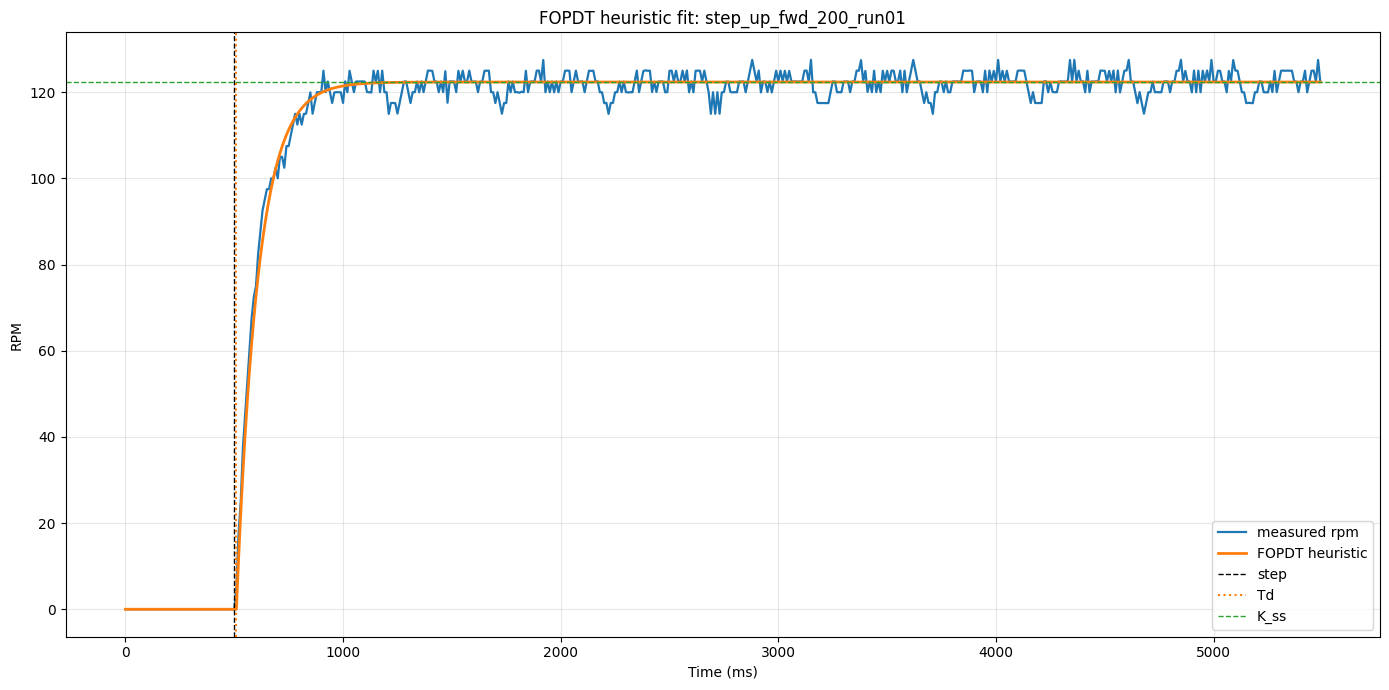

In [11]:
example_key = ("fwd", 200, 1)
example = trials[example_key]
fit = fopdt_trial.query("direction == 'fwd' and pwm == 200 and run == 1").iloc[0]
model = fopdt_predict(example["t_ms"], fit["K_ss"], fit["Td_ms"], fit["tau_ms"])

fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(example["t_ms"], example["rpm"], label="measured rpm", linewidth=1.6)
ax.plot(example["t_ms"], model, label="FOPDT heuristic", linewidth=2.0)
ax.axvline(STEP_START_MS, color="black", linestyle="--", linewidth=1.0, label="step")
ax.axvline(STEP_START_MS + fit["Td_ms"], color="tab:orange", linestyle=":", linewidth=1.5, label="Td")
ax.axhline(fit["K_ss"], color="tab:green", linestyle="--", linewidth=1.0, label="K_ss")
ax.set_title("FOPDT heuristic fit: step_up_fwd_200_run01")
ax.set_xlabel("Time (ms)")
ax.set_ylabel("RPM")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
out = FIG_DIR / "05_fopdt_fwd_200_run01.png"
fig.savefig(out, dpi=100)
print(f"Saved {out}")
plt.show()


Saved /Users/piyush/code/System_Identification_DC_Motor/figures/06_fopdt_6condition_grid.png


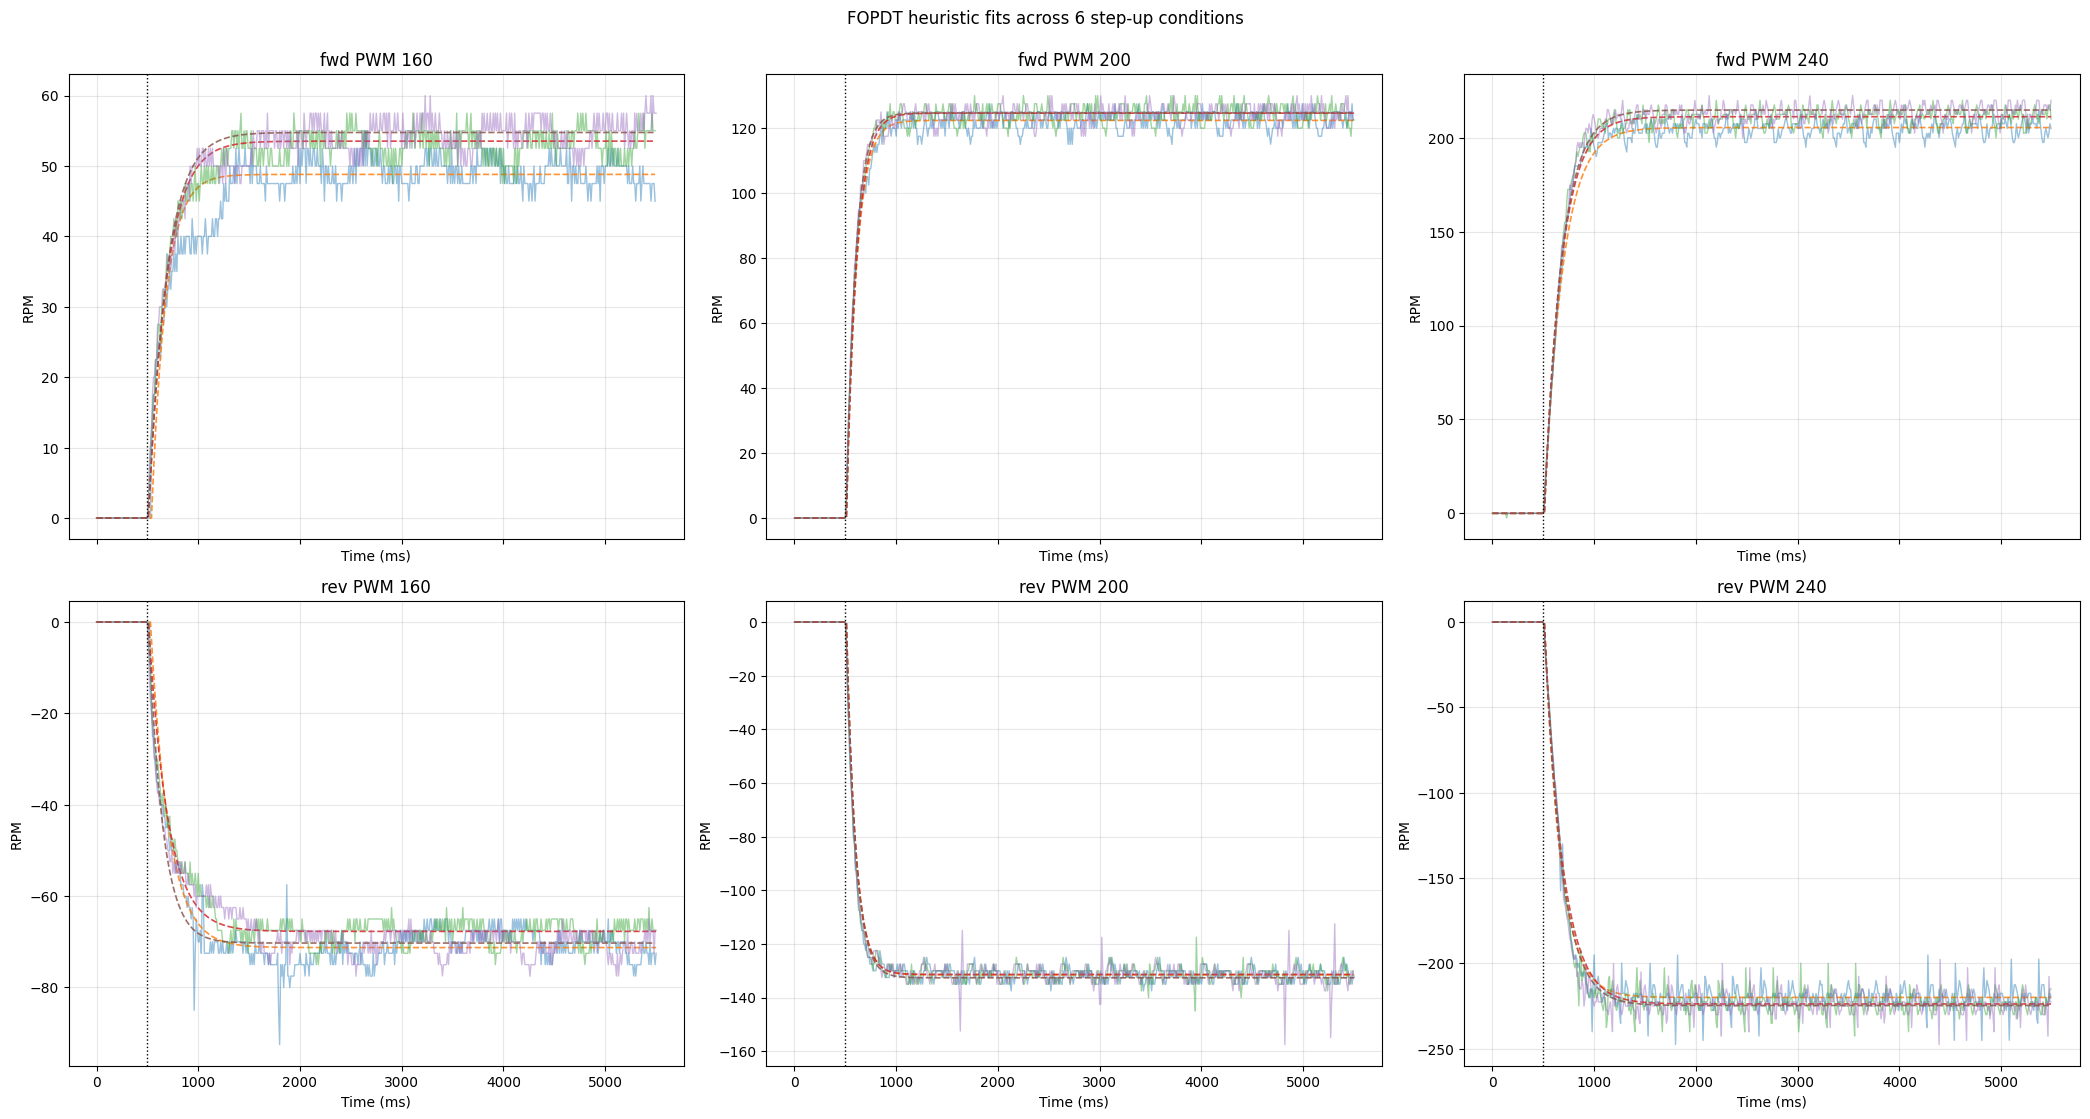

In [12]:
conditions = [("fwd", 160), ("fwd", 200), ("fwd", 240), ("rev", 160), ("rev", 200), ("rev", 240)]
fig, axes = plt.subplots(2, 3, figsize=(21, 11.2), sharex=True)
for ax, (direction, pwm) in zip(axes.ravel(), conditions):
    for run in sorted(r for (d, p, r) in trials if d == direction and p == pwm):
        df = trials[(direction, pwm, run)]
        fit = fopdt_trial.query("direction == @direction and pwm == @pwm and run == @run").iloc[0]
        model = fopdt_predict(df["t_ms"], fit["K_ss"], fit["Td_ms"], fit["tau_ms"])
        ax.plot(df["t_ms"], df["rpm"], alpha=0.45, linewidth=1.0)
        ax.plot(df["t_ms"], model, alpha=0.85, linewidth=1.2, linestyle="--")
    ax.axvline(STEP_START_MS, color="black", linestyle=":", linewidth=1.0)
    ax.set_title(f"{direction} PWM {pwm}")
    ax.grid(True, alpha=0.3)
    ax.set_xlabel("Time (ms)")
    ax.set_ylabel("RPM")
fig.suptitle("FOPDT heuristic fits across 6 step-up conditions", y=0.995)
fig.tight_layout()
out = FIG_DIR / "06_fopdt_6condition_grid.png"
fig.savefig(out, dpi=100)
print(f"Saved {out}")
plt.show()


Saved /Users/piyush/code/System_Identification_DC_Motor/figures/07_tau_td_vs_pwm.png


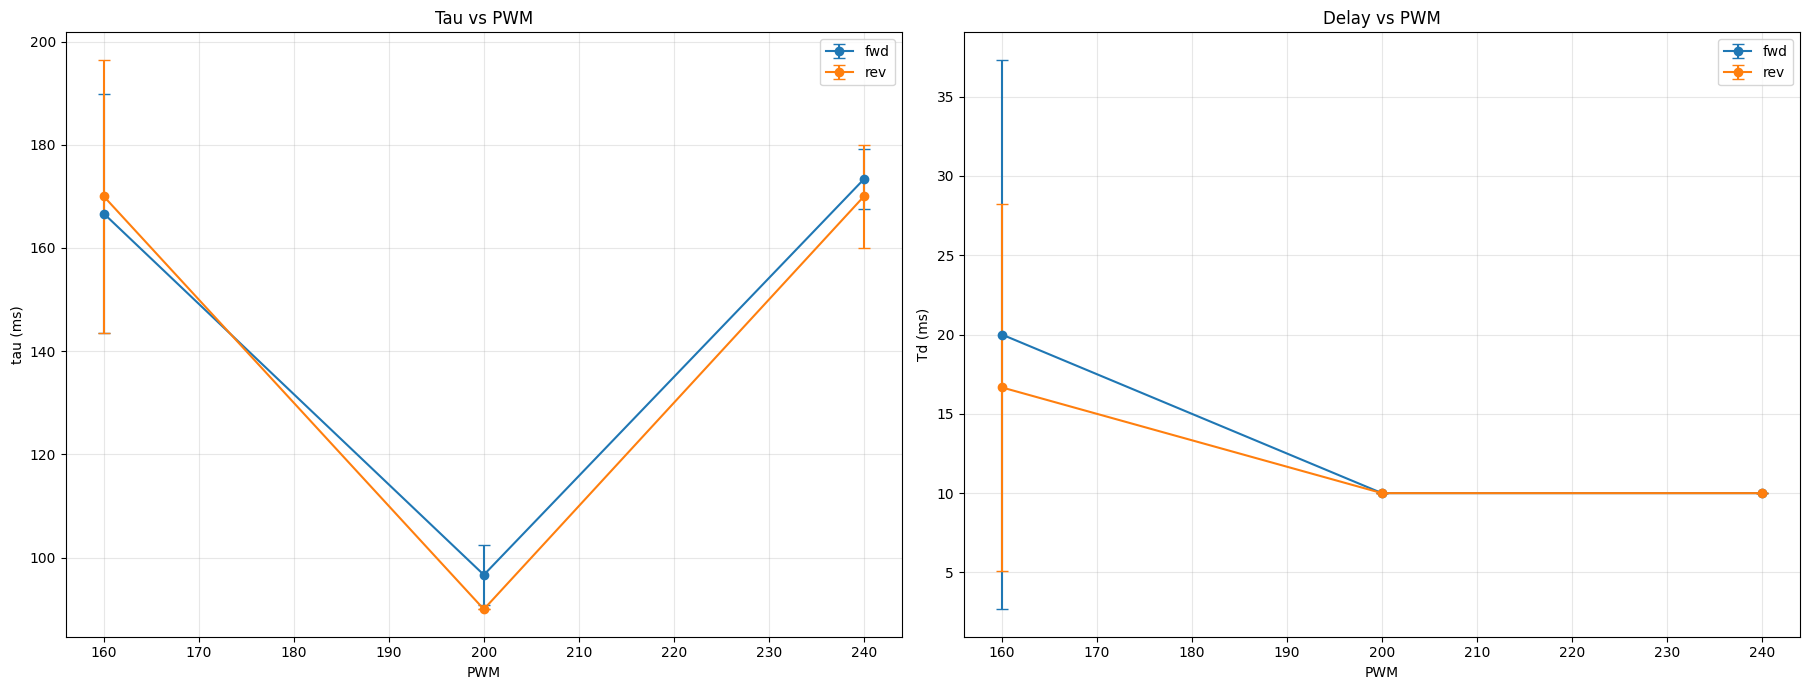

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(18.2, 7))
for direction, group in fopdt_condition.groupby("direction"):
    group = group.sort_values("pwm")
    axes[0].errorbar(group["pwm"], group["tau_mean"], yerr=group["tau_std"], marker="o", capsize=4, label=direction)
    axes[1].errorbar(group["pwm"], group["Td_mean"], yerr=group["Td_std"], marker="o", capsize=4, label=direction)

axes[0].set_title("Tau vs PWM")
axes[0].set_xlabel("PWM")
axes[0].set_ylabel("tau (ms)")
axes[1].set_title("Delay vs PWM")
axes[1].set_xlabel("PWM")
axes[1].set_ylabel("Td (ms)")
for ax in axes:
    ax.grid(True, alpha=0.3)
    ax.legend()
fig.tight_layout()
out = FIG_DIR / "07_tau_td_vs_pwm.png"
fig.savefig(out, dpi=100)
print(f"Saved {out}")
plt.show()
